# Session 12: Causal Inference & Directed Acyclic Graphs

**Bayesian Analysis of Empirical Data (2026)**  
*Author: Irina Knyazeva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iknyazeva/bayes-cogsci-book/blob/main/notebooks/colab/12_causal_inference.ipynb)

In this laboratory, we explore the difference between passive observation and active intervention, examine the Sesame Street randomized encouragement evaluation (Gelman et al., *ROS* Ch. 18), and demonstrate why conditioning on colliders induces severe selection bias.

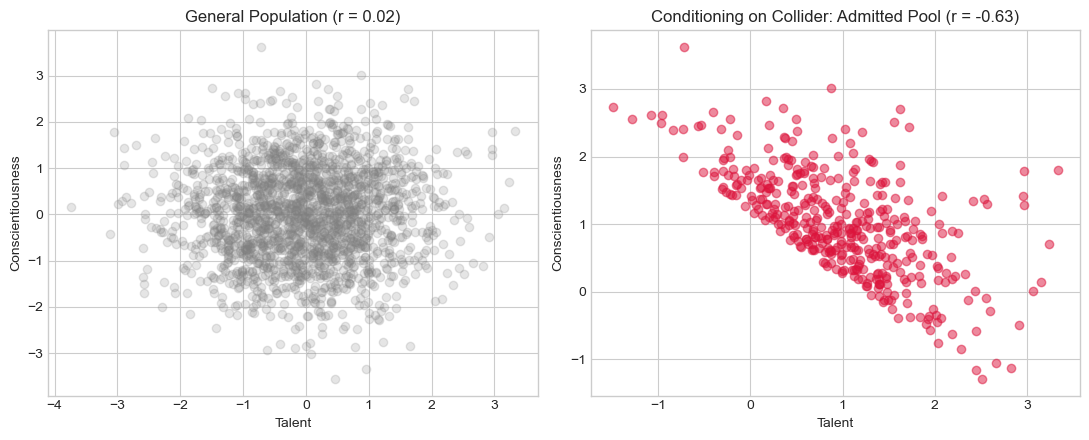

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
import pymc as pm

plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
rng = np.random.default_rng(2026)

# Simulation: The Collider Bias Trap (X -> C <- Y)
# X: Talent, Y: Conscientiousness (independent in nature)
N_pop = 2000
talent = rng.normal(0, 1, size=N_pop)
conscientiousness = rng.normal(0, 1, size=N_pop)

# C: Admission to elite university (conditioned on top 20% composite score)
score = talent + conscientiousness
admitted = score > np.percentile(score, 80)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.5))
ax1.scatter(talent, conscientiousness, alpha=0.2, color="gray")
ax1.set_title(f"General Population (r = {np.corrcoef(talent, conscientiousness)[0,1]:.2f})")
ax1.set_xlabel("Talent")
ax1.set_ylabel("Conscientiousness")

ax2.scatter(talent[admitted], conscientiousness[admitted], alpha=0.5, color="crimson")
r_admitted = np.corrcoef(talent[admitted], conscientiousness[admitted])[0,1]
ax2.set_title(f"Conditioning on Collider: Admitted Pool (r = {r_admitted:.2f})")
ax2.set_xlabel("Talent")
ax2.set_ylabel("Conscientiousness")
plt.tight_layout()
plt.show()

## 1. Sesame Street Evaluation: Intention-to-Treat (ITT) Estimation in PyMC

In [2]:
# Synthetic replica of Sesame Street randomized encouragement experiment (N = 240)
N_sesame = 240
encouraged = rng.binomial(1, 0.5, size=N_sesame)  # Randomized encouragement T
pre_score = rng.normal(50, 12, size=N_sesame)      # Pretreatment baseline X
# True ITT effect = +8 points; baseline score has slope = 0.65
post_score = 15 + 8.0 * encouraged + 0.65 * pre_score + rng.normal(0, 8, size=N_sesame)

with pm.Model() as itt_model:
    alpha = pm.Normal("alpha", mu=50, sigma=20)
    beta_itt = pm.Normal("beta_itt", mu=0, sigma=10)
    beta_pre = pm.Normal("beta_pre", mu=1, sigma=0.5)
    sigma = pm.HalfNormal("sigma", sigma=15)
    
    mu = alpha + beta_itt * encouraged + beta_pre * (pre_score - 50.0)
    y_obs = pm.Normal("post_score", mu=mu, sigma=sigma, observed=post_score)
    
    idata_itt = pm.sample(draws=1000, tune=1000, chains=4, random_seed=2026, return_inferencedata=True)

post = idata_itt.posterior
itt_draws = post["beta_itt"].values.flatten()
print(f"Estimated Causal ITT Effect: {itt_draws.mean():.2f} points [95% HDI: {np.percentile(itt_draws, 2.5):.2f}, {np.percentile(itt_draws, 97.5):.2f}]")

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [alpha, beta_itt, beta_pre, sigma]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


Estimated Causal ITT Effect: 6.59 points [95% HDI: 4.67, 8.66]
